In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "functions"))

In [2]:
from signal_processing import load_raw_gdf, rename_and_montage, bandpass_filter, run_ica, apply_ica, epoch_raw, compute_tfr, get_motor_events
from dataset import log_normalize, build_and_save_dataset, log_transform
from train import run_loso_optimized

import matplotlib.pyplot as plt
import numpy as np
import mne

In [3]:
gdf_path_1 = Path.cwd().parent / "data" / "BCICIV_2a_gdf" / "A01T.gdf"
gdf_path_2 = Path.cwd().parent / "data" / "BCICIV_2a_gdf" / "A02T.gdf"
gdf_path_3 = Path.cwd().parent / "data" / "BCICIV_2a_gdf" / "A03T.gdf"

In [4]:
exclude_map = {
    1: [0],
    2: [0],
    3: [0]
}

In [ ]:
outdir = "../data/processed_ICA_1-3"
build_and_save_dataset([1,2,3], outdir, exclude_map=exclude_map)

processing subject 1...
Extracting GDF parameters from /Users/ashvath/eeg-wheelchair-control/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.4s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 9.8s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 5.0s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

In [3]:
subject_ids = [1, 2, 3]
accuracies, mean = run_loso_optimized(subject_ids, n_epochs=50, batch_size=32, data_dir="../data/processed_ICA_1-3")

/Users/ashvath/eeg-wheelchair-control/functions/dataset.py:263: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  x = torch.from_numpy(self.X_list[subject_idx][local_idx]).float()


[Subject 1] Epoch 1/50 | Train Loss: 1.4426 | Val Loss: 1.3912
[Subject 1] Epoch 2/50 | Train Loss: 1.3849 | Val Loss: 1.3660
[Subject 1] Epoch 3/50 | Train Loss: 1.3486 | Val Loss: 1.3526
[Subject 1] Epoch 4/50 | Train Loss: 1.2850 | Val Loss: 1.3478
[Subject 1] Epoch 5/50 | Train Loss: 1.2784 | Val Loss: 1.3166
[Subject 1] Epoch 6/50 | Train Loss: 1.2334 | Val Loss: 1.3134
[Subject 1] Epoch 7/50 | Train Loss: 1.2368 | Val Loss: 1.3018
[Subject 1] Epoch 8/50 | Train Loss: 1.1994 | Val Loss: 1.2850
[Subject 1] Epoch 9/50 | Train Loss: 1.1683 | Val Loss: 1.2728
[Subject 1] Epoch 10/50 | Train Loss: 1.1384 | Val Loss: 1.2731
[Subject 1] Epoch 11/50 | Train Loss: 1.1286 | Val Loss: 1.2655
[Subject 1] Epoch 12/50 | Train Loss: 1.1188 | Val Loss: 1.2459
[Subject 1] Epoch 13/50 | Train Loss: 1.0873 | Val Loss: 1.2553
[Subject 1] Epoch 14/50 | Train Loss: 1.0888 | Val Loss: 1.2324
[Subject 1] Epoch 15/50 | Train Loss: 1.0706 | Val Loss: 1.2268
[Subject 1] Epoch 16/50 | Train Loss: 1.0713 | Va

In [7]:
for s in [1, 2, 3]:
    y = np.load(f"../data/processed_ICA_1-3/subject_{s}_y.npy")
    print(f"Subject {s}: {np.unique(y, return_counts=True)}")

Subject 1: (array([0, 1, 2, 3]), array([72, 72, 72, 72]))
Subject 2: (array([0, 1, 2, 3]), array([72, 72, 72, 72]))
Subject 3: (array([0, 1, 2, 3]), array([72, 72, 72, 72]))


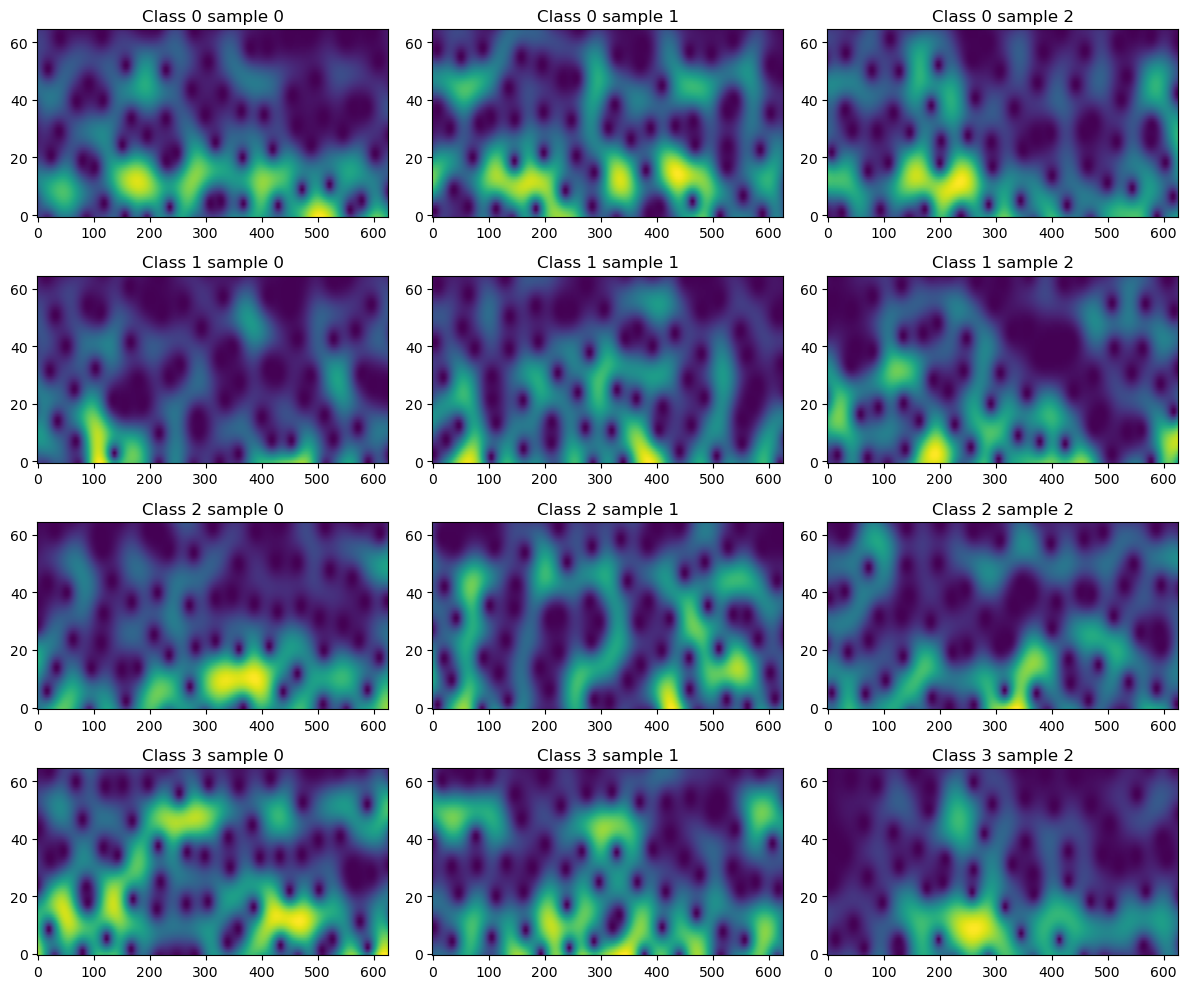

In [8]:
X = np.load("../data/processed_ICA_1-3/subject_1_X.npy")
y = np.load("../data/processed_ICA_1-3/subject_1_y.npy")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
for class_idx in range(4):
    samples = X[y == class_idx][:3]  # 3 samples per class
    for i, sample in enumerate(samples):
        axes[class_idx, i].imshow(sample[7], aspect='auto', origin='lower')  # channel C3
        axes[class_idx, i].set_title(f"Class {class_idx} sample {i}")
plt.tight_layout()
plt.show()

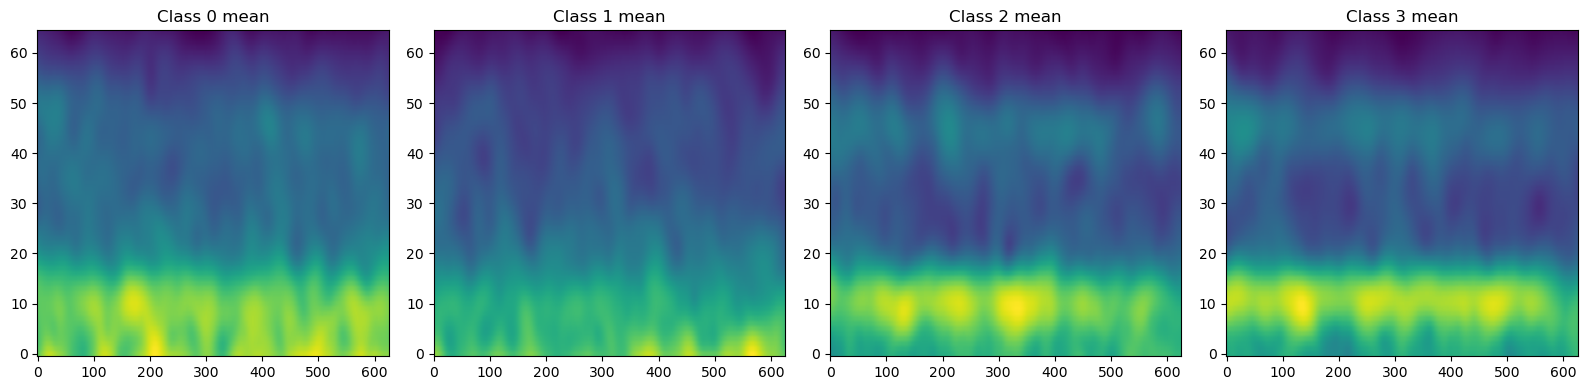

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for class_idx in range(4):
    samples = X[y == class_idx]
    mean_tfr = samples[:, 7, :, :].mean(axis=0)  # avg over all trials, channel C3
    axes[class_idx].imshow(mean_tfr, aspect='auto', origin='lower')
    axes[class_idx].set_title(f"Class {class_idx} mean")
plt.tight_layout()
plt.show()

In [11]:
exclude_map = {}
build_and_save_dataset([1,2,3,4,5,6], "../data/processed_global_norm", exclude_map=exclude_map)


processing subject 1...
Extracting GDF parameters from /Users/ashvath/eeg-wheelchair-control/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.5s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 9.9s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.1s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 5.0s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

/opt/anaconda3/envs/ckd_env/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 3.00, 35.00 Hz: -6.02, -6.02 dB

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 8.3s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samp

In [13]:
subject_ids = [1, 2, 3, 4, 5, 6]
accuracies, mean = run_loso_optimized(subject_ids, n_epochs=50, batch_size=32, data_dir="../data/processed_global_norm")

[Subject 1] Epoch 1/50 | Train Loss: 1.5039 | Val Loss: 1.4221
[Subject 1] Epoch 2/50 | Train Loss: 1.3509 | Val Loss: 1.4275
[Subject 1] Epoch 3/50 | Train Loss: 1.2498 | Val Loss: 1.4201
[Subject 1] Epoch 4/50 | Train Loss: 1.1859 | Val Loss: 1.4186
[Subject 1] Epoch 5/50 | Train Loss: 1.1616 | Val Loss: 1.4244
[Subject 1] Epoch 6/50 | Train Loss: 1.0738 | Val Loss: 1.4392
[Subject 1] Epoch 7/50 | Train Loss: 1.0595 | Val Loss: 1.4395
[Subject 1] Epoch 8/50 | Train Loss: 0.9777 | Val Loss: 1.4916
[Subject 1] Epoch 9/50 | Train Loss: 0.9899 | Val Loss: 1.5076
[Subject 1] Epoch 10/50 | Train Loss: 0.9327 | Val Loss: 1.4978
[Subject 1] Epoch 11/50 | Train Loss: 0.9329 | Val Loss: 1.5251
[Subject 1] Epoch 12/50 | Train Loss: 0.8864 | Val Loss: 1.5243
[Subject 1] Epoch 13/50 | Train Loss: 0.8431 | Val Loss: 1.5939
[Subject 1] Epoch 14/50 | Train Loss: 0.8021 | Val Loss: 1.6016
[Subject 1] Early stopping at epoch 14
[Subject 1] Accuracy: 0.3785

[Subject 2] Epoch 1/50 | Train Loss: 1.4326 